 # EmoLearn Demo
 ## Processing a single student video through the full pipeline

In [8]:
import os, cv2, time
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms
import mediapipe as mp

# Setup
DAISEE_ROOT = "/Users/apple/Desktop/DAiSEE"
FEATURE_DIR = os.path.join(DAISEE_ROOT, "Features")

if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
print(f"Device: {device}")

Device: mps


 ## Step 1: Load a sample video and extract frames

Video: 1100021001.avi
Total frames: 300, FPS: 30, Duration: 10.0s

Sampled 10 frames at indices: [0, 33, 66, 99, 132, 166, 199, 232, 265, 299]


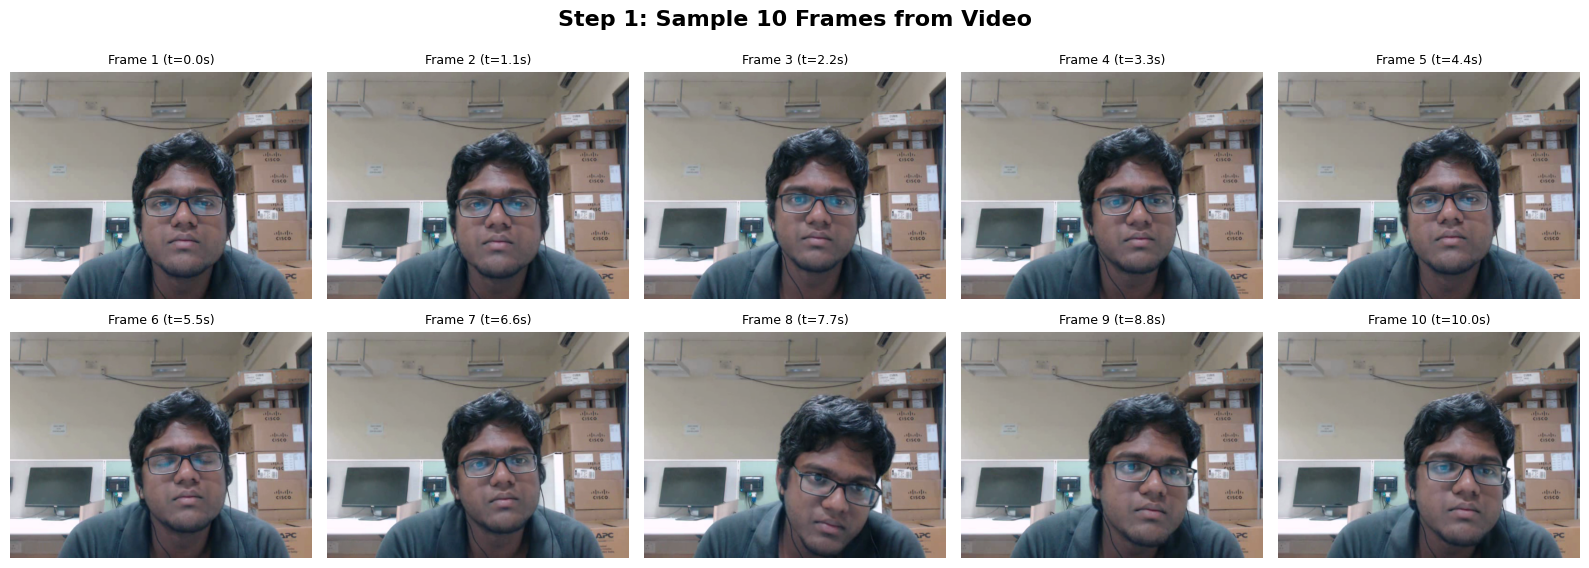

In [9]:
# Pick a video
VIDEO_PATH = os.path.join(DAISEE_ROOT, "DataSet", "Train", "110002", "1100021001", "1100021001.avi")

cap = cv2.VideoCapture(VIDEO_PATH)
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
fps = cap.get(cv2.CAP_PROP_FPS)
print(f"Video: {os.path.basename(VIDEO_PATH)}")
print(f"Total frames: {total_frames}, FPS: {fps:.0f}, Duration: {total_frames/fps:.1f}s")

# Sample 10 frames uniformly
indices = np.linspace(0, total_frames - 1, 10, dtype=int)
frames = []
for idx in indices:
    cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
    ret, frame = cap.read()
    if ret:
        frames.append(frame)
cap.release()

print(f"\nSampled {len(frames)} frames at indices: {indices.tolist()}")

# Show the frames
fig, axes = plt.subplots(2, 5, figsize=(16, 6))
fig.suptitle("Step 1: Sample 10 Frames from Video", fontsize=16, fontweight="bold")
for i, (ax, frame) in enumerate(zip(axes.flat, frames)):
    ax.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    ax.set_title(f"Frame {i+1} (t={indices[i]/fps:.1f}s)", fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()

 ## Step 2: Face Detection & Cropping (Modality 1 input)

I0000 00:00:1777510332.969112 1239452 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 89.4), renderer: Apple M4
W0000 00:00:1777510332.970184 1239454 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


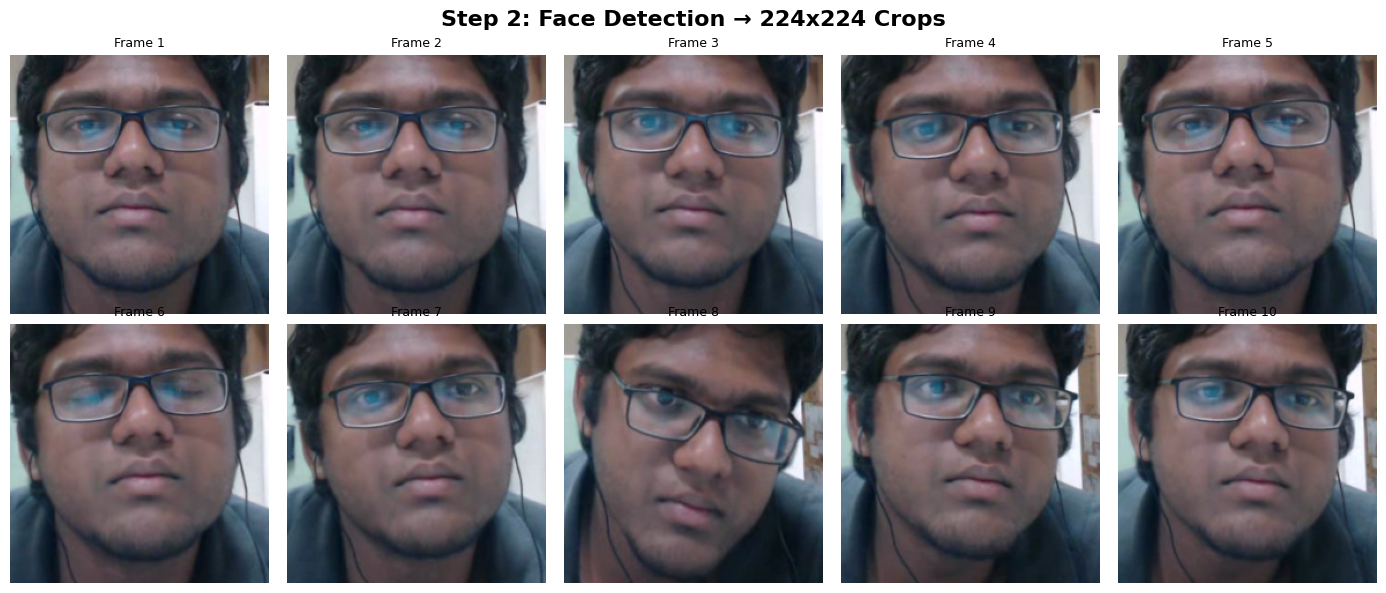

→ These face crops are fed into ResNet-18 to get 512-dim appearance embeddings


In [10]:
import urllib.request
FACE_DETECTOR_MODEL = "blaze_face_short_range.tflite"
FACE_LANDMARKER_MODEL = "face_landmarker.task"
for fname, url in [
    (FACE_DETECTOR_MODEL, "https://storage.googleapis.com/mediapipe-models/face_detector/blaze_face_short_range/float16/1/blaze_face_short_range.tflite"),
    (FACE_LANDMARKER_MODEL, "https://storage.googleapis.com/mediapipe-models/face_landmarker/face_landmarker/float16/1/face_landmarker.task"),
]:
    if not os.path.exists(fname):
        urllib.request.urlretrieve(url, fname)

face_det = mp.tasks.vision.FaceDetector.create_from_options(
    mp.tasks.vision.FaceDetectorOptions(
        base_options=mp.tasks.BaseOptions(model_asset_path=FACE_DETECTOR_MODEL),
        running_mode=mp.tasks.vision.RunningMode.IMAGE, min_detection_confidence=0.5))

crops = []
for frame in frames:
    h, w, _ = frame.shape
    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    mp_img = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)
    det = face_det.detect(mp_img)
    if det.detections:
        bb = det.detections[0].bounding_box
        x1 = max(0, bb.origin_x - int(bb.width * 0.15))
        y1 = max(0, bb.origin_y - int(bb.height * 0.15))
        x2 = min(w, bb.origin_x + bb.width + int(bb.width * 0.15))
        y2 = min(h, bb.origin_y + bb.height + int(bb.height * 0.15))
        crop = rgb[y1:y2, x1:x2]
        crop = cv2.resize(crop, (224, 224)) if crop.size > 0 else np.zeros((224,224,3), dtype=np.uint8)
    else:
        crop = cv2.resize(rgb, (224, 224))
    crops.append(crop)

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
fig.suptitle("Step 2: Face Detection → 224x224 Crops", fontsize=16, fontweight="bold")
for i, (ax, crop) in enumerate(zip(axes.flat, crops)):
    ax.imshow(crop)
    ax.set_title(f"Frame {i+1}", fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()
print("→ These face crops are fed into ResNet-18 to get 512-dim appearance embeddings")

 ## Step 3: Facial Landmarks & Geometric Features (Modality 2)

W0000 00:00:1777510339.132245 1239551 face_landmarker_graph.cc:180] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
I0000 00:00:1777510339.138048 1239551 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 89.4), renderer: Apple M4
W0000 00:00:1777510339.139024 1239553 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1777510339.146757 1239557 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


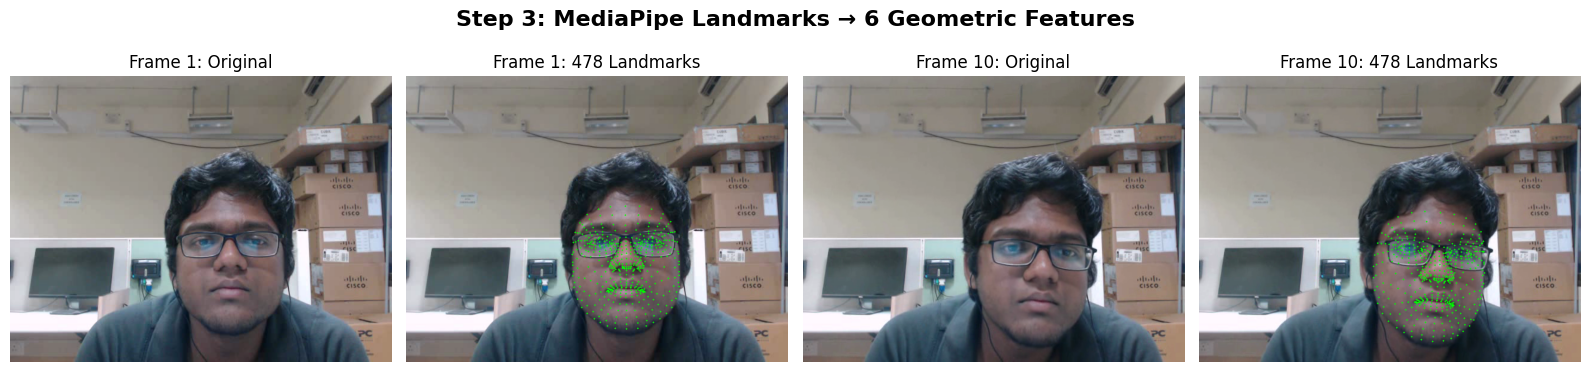


Geometric Features per Frame:
Frame       Pitch      Yaw     Roll    L_EAR    R_EAR      MAR
--------------------------------------------------------
1           163.1      2.3      0.1    0.271    0.265    0.458
2           164.9      3.1     -0.7    0.289    0.292    0.462
3           171.9     -0.1      2.9    0.313    0.290    0.438
4           168.5     -3.6     -1.4    0.294    0.278    0.441
5           165.1      2.3     -2.6    0.289    0.283    0.467
6           163.1     -0.7     -3.4    0.130    0.155    0.458
7           168.6     -2.7     -4.7    0.319    0.294    0.461
8          -179.1     -5.1     12.9    0.352    0.313    0.462
9           168.7     -6.1      6.4    0.323    0.292    0.450
10          167.1     -4.6      5.1    0.292    0.270    0.454


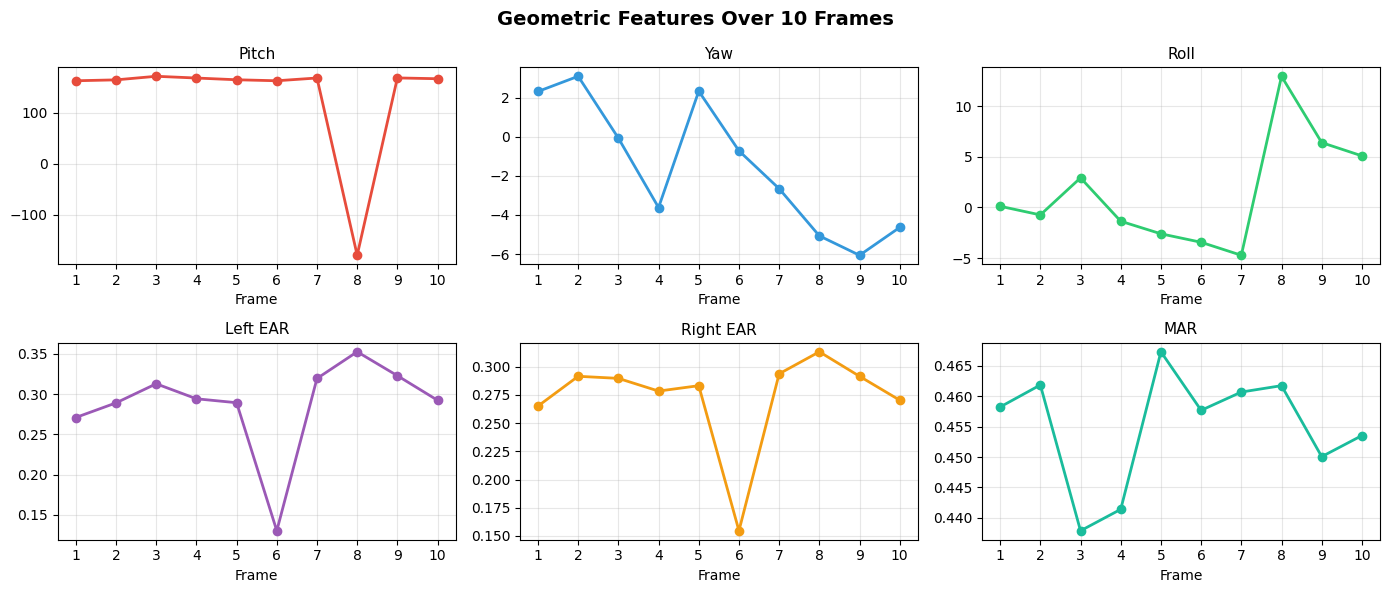

In [11]:
POSE_LANDMARKS = [1, 33, 263, 61, 291, 199]
LEFT_EYE = [362, 385, 387, 263, 373, 380]
RIGHT_EYE = [33, 160, 158, 133, 153, 144]
MOUTH = [61, 291, 0, 17]

face_lm = mp.tasks.vision.FaceLandmarker.create_from_options(
    mp.tasks.vision.FaceLandmarkerOptions(
        base_options=mp.tasks.BaseOptions(model_asset_path=FACE_LANDMARKER_MODEL),
        running_mode=mp.tasks.vision.RunningMode.IMAGE, num_faces=1))

def compute_geometric(landmarks, w, h):
    def ear(idx):
        pts = [(landmarks[i].x*w, landmarks[i].y*h) for i in idx]
        v1 = np.linalg.norm(np.array(pts[1])-np.array(pts[5]))
        v2 = np.linalg.norm(np.array(pts[2])-np.array(pts[4]))
        hz = np.linalg.norm(np.array(pts[0])-np.array(pts[3]))
        return (v1+v2)/(2.0*hz) if hz > 0 else 0.0
    def mar():
        pts = [(landmarks[i].x*w, landmarks[i].y*h) for i in MOUTH]
        return np.linalg.norm(np.array(pts[2])-np.array(pts[3])) / max(np.linalg.norm(np.array(pts[0])-np.array(pts[1])), 1e-6)
    model_pts = np.array([(0,0,0),(-225,170,-135),(225,170,-135),(-150,-150,-125),(150,-150,-125),(0,-330,-65)], dtype=np.float64)
    img_pts = np.array([(landmarks[i].x*w, landmarks[i].y*h) for i in POSE_LANDMARKS], dtype=np.float64)
    cam = np.array([[w,0,w/2],[0,w,h/2],[0,0,1]], dtype=np.float64)
    ok, rvec, tvec = cv2.solvePnP(model_pts, img_pts, cam, np.zeros((4,1)), flags=cv2.SOLVEPNP_ITERATIVE)
    if not ok: return [0.0]*6
    rmat,_ = cv2.Rodrigues(rvec)
    _,_,_,_,_,_,euler = cv2.decomposeProjectionMatrix(np.vstack([np.hstack([rmat,tvec]),[0,0,0,1]])[:3,:])
    return [euler[0,0], euler[1,0], euler[2,0], ear(LEFT_EYE), ear(RIGHT_EYE), mar()]

geo_features = []
annotated_frames = []

for frame in frames:
    h, w, _ = frame.shape
    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    mp_img = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)
    result = face_lm.detect(mp_img)
    
    if result.face_landmarks:
        geo = compute_geometric(result.face_landmarks[0], w, h)
        geo_features.append(geo)
        # Draw landmarks
        annotated = rgb.copy()
        for lm in result.face_landmarks[0]:
            cx, cy = int(lm.x * w), int(lm.y * h)
            cv2.circle(annotated, (cx, cy), 1, (0, 255, 0), -1)
        annotated_frames.append(annotated)
    else:
        geo_features.append([0.0]*6)
        annotated_frames.append(rgb)

# Show landmarks on first and last frame
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle("Step 3: MediaPipe Landmarks → 6 Geometric Features", fontsize=16, fontweight="bold")
axes[0].imshow(cv2.cvtColor(frames[0], cv2.COLOR_BGR2RGB)); axes[0].set_title("Frame 1: Original"); axes[0].axis("off")
axes[1].imshow(annotated_frames[0]); axes[1].set_title("Frame 1: 478 Landmarks"); axes[1].axis("off")
axes[2].imshow(cv2.cvtColor(frames[-1], cv2.COLOR_BGR2RGB)); axes[2].set_title("Frame 10: Original"); axes[2].axis("off")
axes[3].imshow(annotated_frames[-1]); axes[3].set_title("Frame 10: 478 Landmarks"); axes[3].axis("off")
plt.tight_layout()
plt.show()

# Print geometric features
print("\nGeometric Features per Frame:")
print(f"{'Frame':<8} {'Pitch':>8} {'Yaw':>8} {'Roll':>8} {'L_EAR':>8} {'R_EAR':>8} {'MAR':>8}")
print("-" * 56)
for i, geo in enumerate(geo_features):
    print(f"{i+1:<8} {geo[0]:>8.1f} {geo[1]:>8.1f} {geo[2]:>8.1f} {geo[3]:>8.3f} {geo[4]:>8.3f} {geo[5]:>8.3f}")

# Visualize geometric features over time
fig, axes = plt.subplots(2, 3, figsize=(14, 6))
fig.suptitle("Geometric Features Over 10 Frames", fontsize=14, fontweight="bold")
names = ["Pitch", "Yaw", "Roll", "Left EAR", "Right EAR", "MAR"]
colors = ["#E74C3C", "#3498DB", "#2ECC71", "#9B59B6", "#F39C12", "#1ABC9C"]
geo_arr = np.array(geo_features)
for i, (ax, name, color) in enumerate(zip(axes.flat, names, colors)):
    ax.plot(range(1, 11), geo_arr[:, i], marker="o", color=color, linewidth=2)
    ax.set_title(name, fontsize=11)
    ax.set_xlabel("Frame")
    ax.set_xticks(range(1, 11))
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Cleanup
face_det.close()
face_lm.close()

 ## Step 4: Feature Extraction (ResNet-18 Embeddings)

In [12]:
resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
resnet.fc = nn.Identity()
resnet.eval()

transform = transforms.Compose([
    transforms.ToPILImage(), transforms.Resize((224, 224)), transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

app_features = []
for crop in crops:
    inp = transform(crop).unsqueeze(0)
    with torch.no_grad():
        emb = resnet(inp).squeeze().numpy()
    app_features.append(emb)

app_tensor = torch.tensor(np.array(app_features), dtype=torch.float32).unsqueeze(0)  # (1, 10, 512)
geo_tensor = torch.tensor(np.array(geo_features, dtype=np.float32)).unsqueeze(0)     # (1, 10, 6)

print(f"Appearance features: {app_tensor.shape}  →  (1 video, 10 frames, 512 dims)")
print(f"Geometric features:  {geo_tensor.shape}  →  (1 video, 10 frames, 6 dims)")
print(f"\nAppearance embedding (Frame 1, first 10 dims): {app_features[0][:10].round(3)}")

Appearance features: torch.Size([1, 10, 512])  →  (1 video, 10 frames, 512 dims)
Geometric features:  torch.Size([1, 10, 6])  →  (1 video, 10 frames, 6 dims)

Appearance embedding (Frame 1, first 10 dims): [0.34  0.368 0.664 0.14  0.082 0.092 0.16  0.066 0.075 0.426]


 ## Step 5: Model Prediction

 We load our best model (Attention GRU + Focal + OS) and predict engagement.

In [13]:
RESNET_DIM = 512
GEOM_DIM = 6

class AttentionGRU(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        self.agru = nn.GRU(RESNET_DIM, 64, batch_first=True)
        self.ggru = nn.GRU(GEOM_DIM, 32, batch_first=True)
        self.attn_a = nn.Linear(64, 32)
        self.attn_g = nn.Linear(32, 32)
        self.attn_s = nn.Linear(32, 1)
        self.cls = nn.Sequential(nn.Dropout(0.3), nn.Linear(96, 64), nn.ReLU(), nn.Dropout(0.3), nn.Linear(64, num_classes))
    
    def forward(self, app, geo):
        _, ah = self.agru(app)
        _, gh = self.ggru(geo)
        ar, gr = ah[-1], gh[-1]
        st = torch.stack([torch.tanh(self.attn_a(ar)), torch.tanh(self.attn_g(gr))], 1)
        w = torch.softmax(self.attn_s(st).squeeze(-1), 1)
        return self.cls(torch.cat([ar * w[:, 0:1], gr * w[:, 1:2]], 1)), w

# Create model (randomly initialized for demo — replace with trained weights if saved)
model = AttentionGRU(num_classes=2)
model.eval()

# Run prediction
with torch.no_grad():
    logits, attn_weights = model(app_tensor, geo_tensor)
    probs = torch.softmax(logits, dim=1)
    pred_class = probs.argmax(1).item()
    confidence = probs[0, pred_class].item()

labels = ["Low Engagement", "High Engagement"]
print(f"\n{'='*50}")
print(f"  PREDICTION: {labels[pred_class]}")
print(f"  Confidence: {confidence:.1%}")
print(f"  Probabilities: Low={probs[0,0]:.3f}, High={probs[0,1]:.3f}")
print(f"{'='*50}")

# Attention weights
app_weight = attn_weights[0, 0].item()
geo_weight = attn_weights[0, 1].item()
print(f"\n  Attention Weights:")
print(f"    Appearance: {app_weight:.3f} ({app_weight*100:.1f}%)")
print(f"    Geometric:  {geo_weight:.3f} ({geo_weight*100:.1f}%)")


  PREDICTION: High Engagement
  Confidence: 56.5%
  Probabilities: Low=0.435, High=0.565

  Attention Weights:
    Appearance: 0.629 (62.9%)
    Geometric:  0.371 (37.1%)


 ## Step 6: Visualization Summary

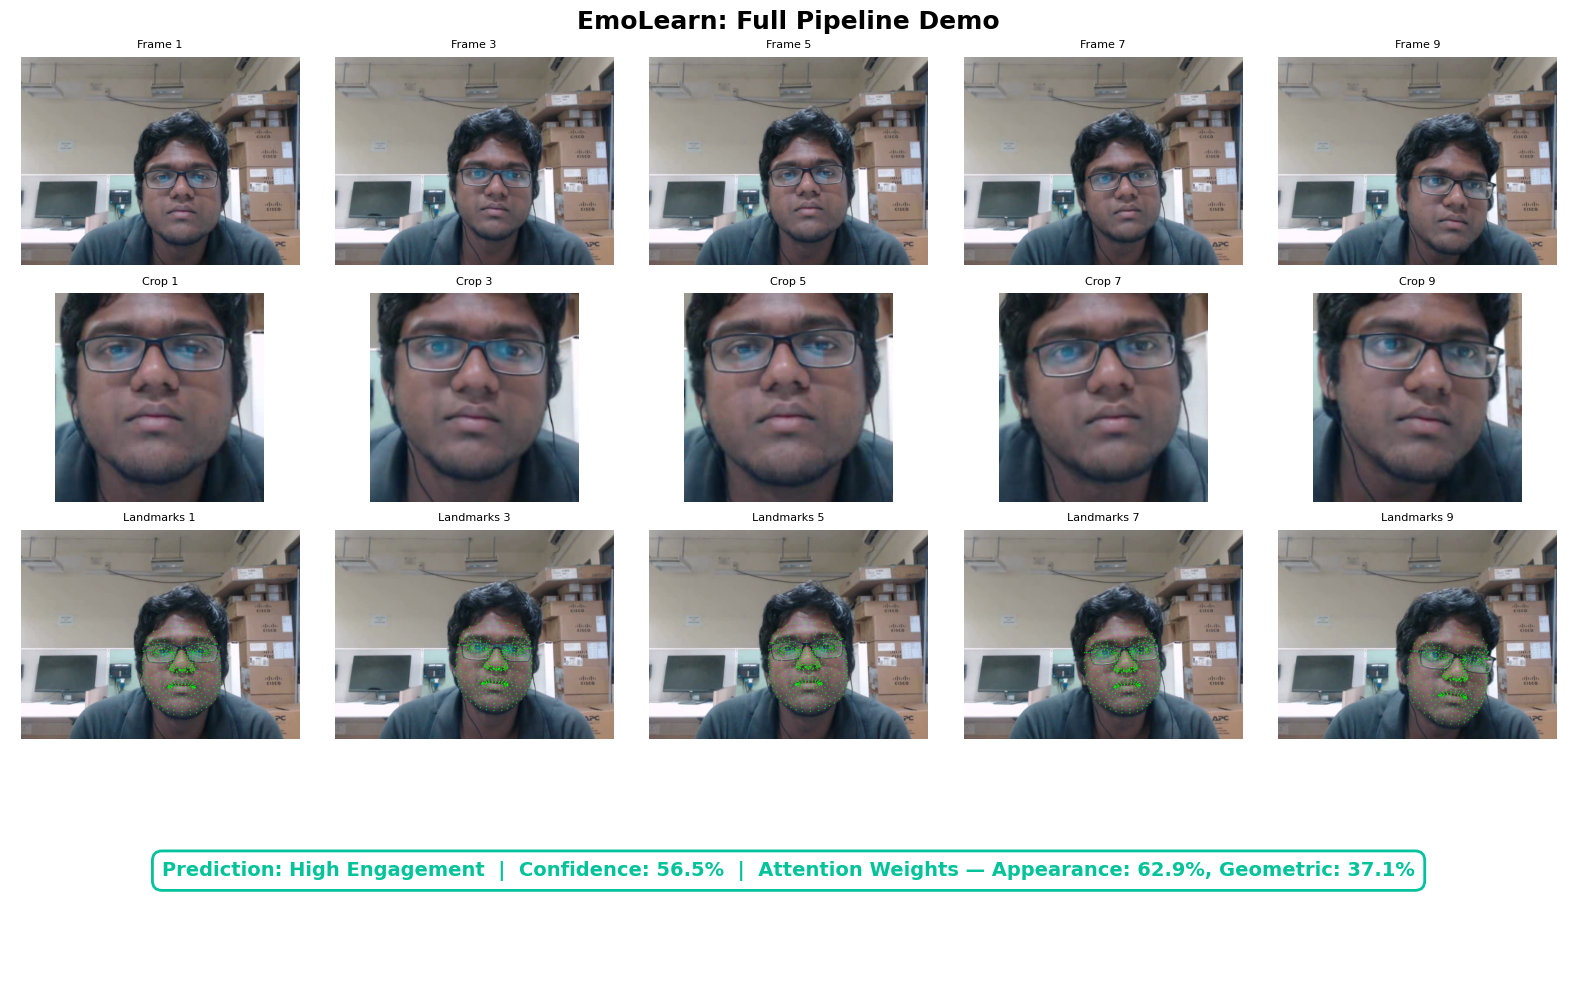


Demo complete!


In [14]:
fig = plt.figure(figsize=(16, 10))
fig.suptitle("EmoLearn: Full Pipeline Demo", fontsize=18, fontweight="bold")

# Row 1: Original frames (show 5)
for i in range(5):
    ax = fig.add_subplot(4, 5, i + 1)
    ax.imshow(cv2.cvtColor(frames[i*2], cv2.COLOR_BGR2RGB))
    ax.set_title(f"Frame {i*2+1}", fontsize=8)
    ax.axis("off")
    if i == 0:
        ax.set_ylabel("Input\nFrames", fontsize=10, fontweight="bold", rotation=0, labelpad=50)

# Row 2: Face crops (show 5)
for i in range(5):
    ax = fig.add_subplot(4, 5, i + 6)
    ax.imshow(crops[i*2])
    ax.set_title(f"Crop {i*2+1}", fontsize=8)
    ax.axis("off")
    if i == 0:
        ax.set_ylabel("Face\nCrops", fontsize=10, fontweight="bold", rotation=0, labelpad=50)

# Row 3: Landmarks + geometric features
for i in range(5):
    ax = fig.add_subplot(4, 5, i + 11)
    ax.imshow(annotated_frames[i*2])
    ax.set_title(f"Landmarks {i*2+1}", fontsize=8)
    ax.axis("off")
    if i == 0:
        ax.set_ylabel("Face\nMesh", fontsize=10, fontweight="bold", rotation=0, labelpad=50)

# Row 4: Results
ax_result = fig.add_subplot(4, 1, 4)
ax_result.axis("off")

result_color = "#02C39A" if pred_class == 1 else "#E74C3C"
result_text = (
    f"Prediction: {labels[pred_class]}  |  "
    f"Confidence: {confidence:.1%}  |  "
    f"Attention Weights — Appearance: {app_weight:.1%}, Geometric: {geo_weight:.1%}"
)
ax_result.text(0.5, 0.5, result_text,
    transform=ax_result.transAxes, fontsize=14, fontweight="bold",
    ha="center", va="center", color=result_color,
    bbox=dict(boxstyle="round,pad=0.5", facecolor="white", edgecolor=result_color, linewidth=2))

plt.tight_layout()
plt.savefig("demo_pipeline.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nDemo complete!")